# 数据集探索 - Oxford Flowers 102

本notebook用于探索和可视化Oxford Flowers 102数据集

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from collections import Counter
import random

# 添加项目路径
sys.path.append('..')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置绘图风格
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. 数据集概览

In [2]:
# 数据集路径
data_dir = '../data'
splits = ['train', 'val', 'test']

# 统计每个split的图片数量
dataset_stats = {}
for split in splits:
    split_dir = os.path.join(data_dir, split)
    if os.path.exists(split_dir):
        classes = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
        total_images = sum([len(os.listdir(os.path.join(split_dir, c))) for c in classes])
        dataset_stats[split] = {
            'classes': len(classes),
            'images': total_images
        }

print("="*60)
print("数据集统计")
print("="*60)
for split, stats in dataset_stats.items():
    print(f"{split.upper():10s}: {stats['images']:5d} 张图片, {stats['classes']:3d} 个类别")
print("="*60)
print(f"总计: {sum([s['images'] for s in dataset_stats.values()])} 张图片")

数据集统计
TRAIN     :  1020 张图片, 102 个类别
VAL       :  1020 张图片, 102 个类别
TEST      :  6149 张图片, 102 个类别
总计: 8189 张图片


## 2. 类别分布

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1626387303.py:16: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1626387303.py:16: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1626387303.py:16: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1626387303.py:16: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1626387303.py:16: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1626387303.py:16: UserWarni

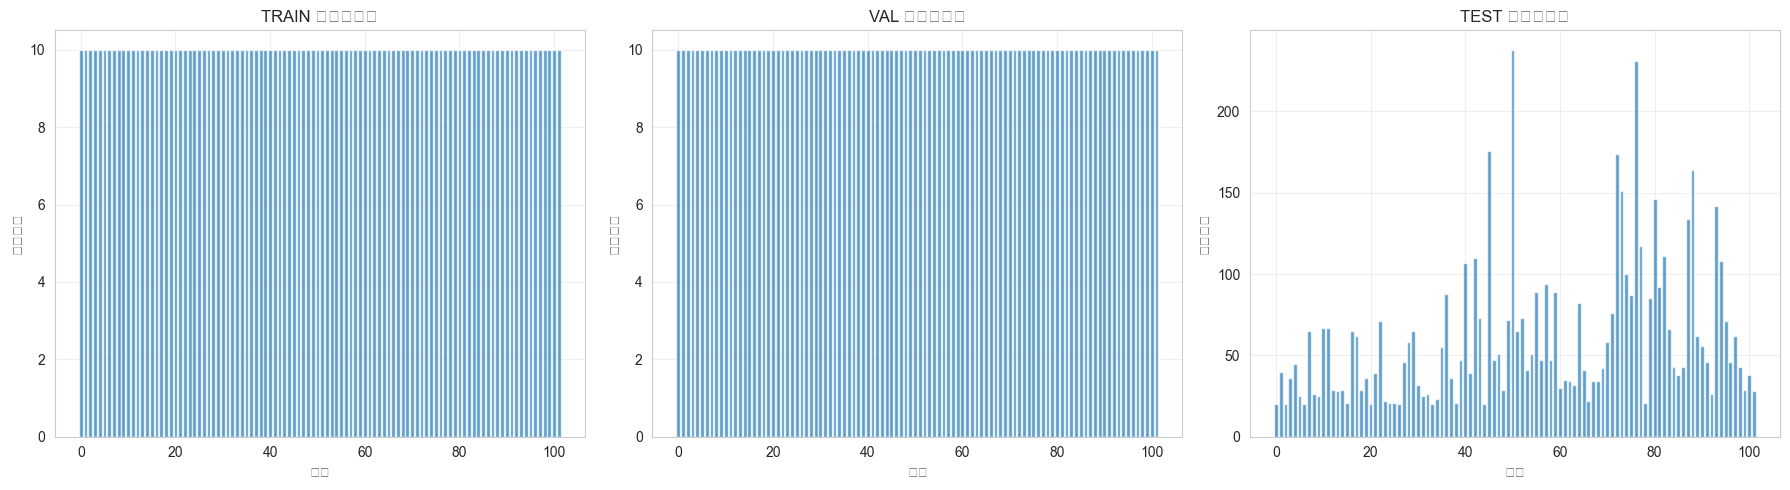

In [3]:
# 分析类别分布
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, split in enumerate(splits):
    split_dir = os.path.join(data_dir, split)
    if os.path.exists(split_dir):
        classes = sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
        class_counts = [len(os.listdir(os.path.join(split_dir, c))) for c in classes]
        
        axes[idx].bar(range(len(classes)), class_counts, alpha=0.7)
        axes[idx].set_title(f'{split.upper()} 集类别分布')
        axes[idx].set_xlabel('类别')
        axes[idx].set_ylabel('图片数量')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 样本可视化

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1587112400.py:32: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1587112400.py:32: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1587112400.py:32: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1587112400.py:32: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1587112400.py:32: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
c:\ProgramData\anaconda3\envs\img_clf\Lib\site-packages\IPython\core\pylabtools.py:17

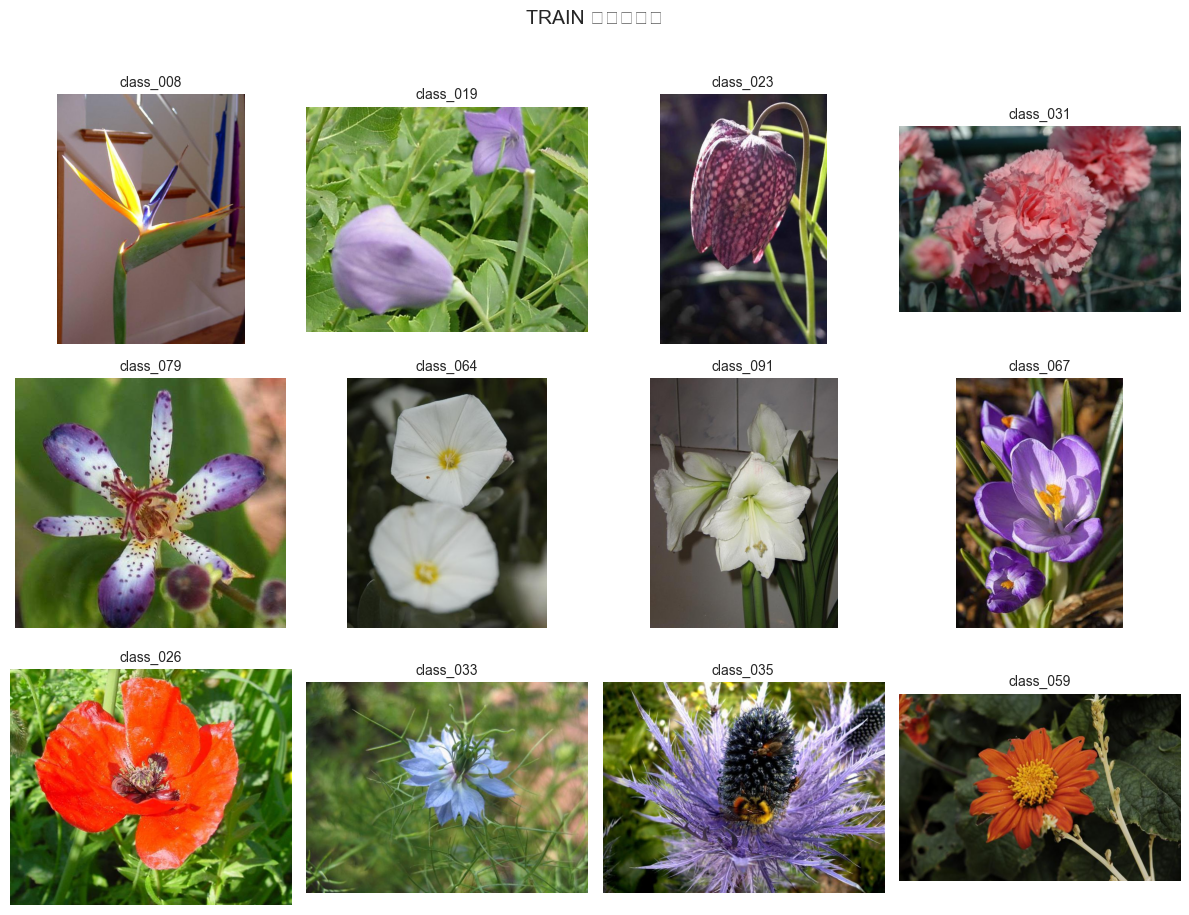

In [4]:
def show_random_samples(split='train', n_samples=12, n_cols=4):
    """
    显示随机样本
    """
    split_dir = os.path.join(data_dir, split)
    classes = sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
    
    # 随机选择类别和图片
    selected_classes = random.sample(classes, min(n_samples, len(classes)))
    
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    axes = axes.flatten() if n_samples > 1 else [axes]
    
    for idx, class_name in enumerate(selected_classes[:n_samples]):
        class_dir = os.path.join(split_dir, class_name)
        images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if images:
            img_path = os.path.join(class_dir, random.choice(images))
            img = Image.open(img_path)
            
            axes[idx].imshow(img)
            axes[idx].set_title(f'{class_name}', fontsize=10)
            axes[idx].axis('off')
    
    # 隐藏多余的子图
    for idx in range(len(selected_classes), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{split.upper()} 集随机样本', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 显示训练集样本
show_random_samples('train', n_samples=12, n_cols=4)

## 4. 图片尺寸分析

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\294659201.py:55: UserWarning: Glyph 23485 (\N{CJK UNIFIED IDEOGRAPH-5BBD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\294659201.py:55: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\294659201.py:55: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\294659201.py:55: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\294659201.py:55: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\294659201.py:55: UserWarning: Gl

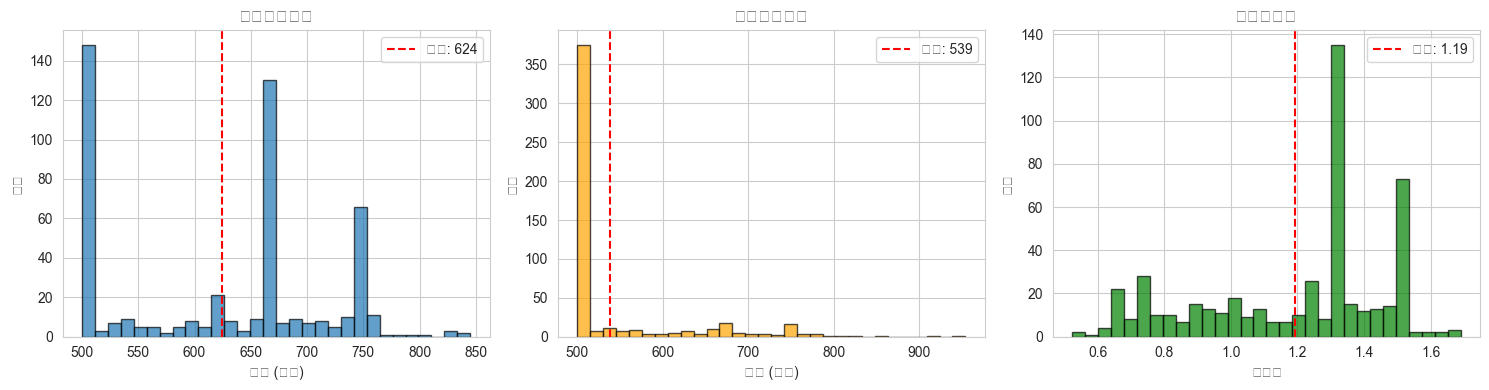

图片尺寸统计 (TRAIN)：
  宽度: 最小=500, 最大=845, 平均=624.1
  高度: 最小=500, 最大=954, 平均=538.6
  宽高比: 最小=0.52, 最大=1.69, 平均=1.19


In [5]:
# 分析图片尺寸
def analyze_image_sizes(split='train', n_samples=500):
    """
    分析图片尺寸分布
    """
    split_dir = os.path.join(data_dir, split)
    classes = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    
    widths, heights, ratios = [], [], []
    
    # 随机采样图片
    all_images = []
    for class_name in classes:
        class_dir = os.path.join(split_dir, class_name)
        images = [os.path.join(class_dir, f) for f in os.listdir(class_dir) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        all_images.extend(images)
    
    sampled_images = random.sample(all_images, min(n_samples, len(all_images)))
    
    for img_path in sampled_images:
        try:
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
            ratios.append(w / h)
        except:
            continue
    
    # 绘制分布
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].hist(widths, bins=30, alpha=0.7, edgecolor='black')
    axes[0].set_title('图片宽度分布')
    axes[0].set_xlabel('宽度 (像素)')
    axes[0].set_ylabel('数量')
    axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'均值: {np.mean(widths):.0f}')
    axes[0].legend()
    
    axes[1].hist(heights, bins=30, alpha=0.7, edgecolor='black', color='orange')
    axes[1].set_title('图片高度分布')
    axes[1].set_xlabel('高度 (像素)')
    axes[1].set_ylabel('数量')
    axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'均值: {np.mean(heights):.0f}')
    axes[1].legend()
    
    axes[2].hist(ratios, bins=30, alpha=0.7, edgecolor='black', color='green')
    axes[2].set_title('宽高比分布')
    axes[2].set_xlabel('宽高比')
    axes[2].set_ylabel('数量')
    axes[2].axvline(np.mean(ratios), color='red', linestyle='--', label=f'均值: {np.mean(ratios):.2f}')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"图片尺寸统计 ({split.upper()})：")
    print(f"  宽度: 最小={min(widths)}, 最大={max(widths)}, 平均={np.mean(widths):.1f}")
    print(f"  高度: 最小={min(heights)}, 最大={max(heights)}, 平均={np.mean(heights):.1f}")
    print(f"  宽高比: 最小={min(ratios):.2f}, 最大={max(ratios):.2f}, 平均={np.mean(ratios):.2f}")

analyze_image_sizes('train', n_samples=500)

## 5. 数据增强预览

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1994052762.py:33: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1994052762.py:33: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1994052762.py:33: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1994052762.py:33: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1994052762.py:33: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33472\1994052762.py:33: UserWarni

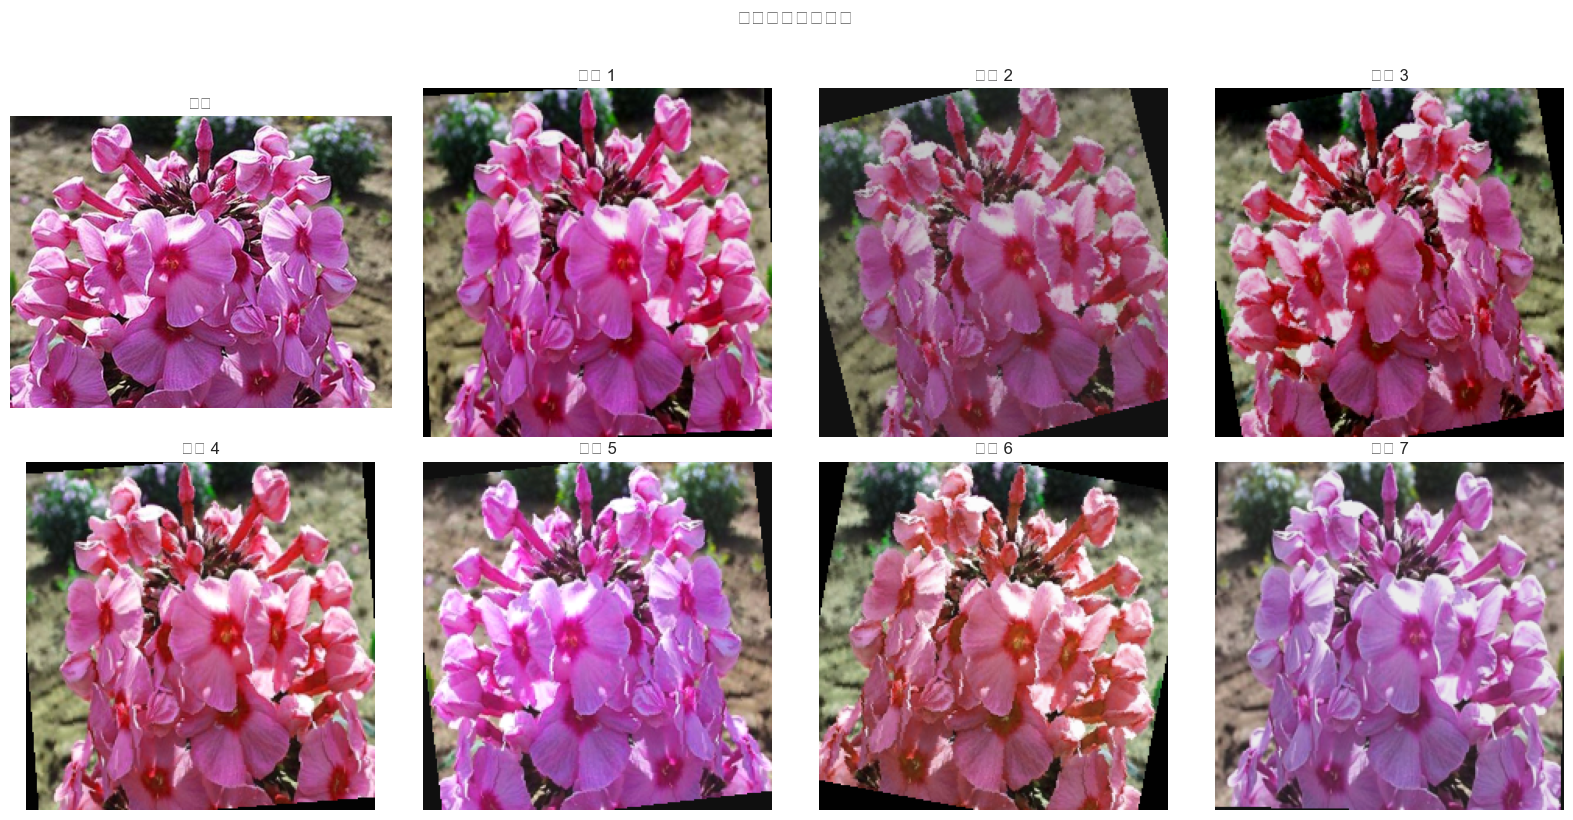

In [6]:
from torchvision import transforms

# 定义数据增强
augmentation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

def show_augmentations(image_path, n_augmentations=8):
    """
    显示数据增强效果
    """
    img = Image.open(image_path)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # 原图
    axes[0].imshow(img)
    axes[0].set_title('原图', fontsize=12)
    axes[0].axis('off')
    
    # 增强后的图
    for idx in range(1, n_augmentations):
        aug_img = augmentation(img)
        axes[idx].imshow(aug_img)
        axes[idx].set_title(f'增强 {idx}', fontsize=12)
        axes[idx].axis('off')
    
    plt.suptitle('数据增强效果预览', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 随机选择一张图片
train_dir = os.path.join(data_dir, 'train')
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
random_class = random.choice(classes)
class_dir = os.path.join(train_dir, random_class)
images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random_image = os.path.join(class_dir, random.choice(images))

show_augmentations(random_image, n_augmentations=8)

## 6. 数据处理建议

根据数据集分析，建议：

1. **图片尺寸**: 统一调整为 224x224（适合大多数预训练模型）
2. **数据增强**:
   - 随机水平翻转
   - 随机旋转（±15度）
   - 颜色抖动（亮度、对比度、饱和度）
   - 随机裁剪和缩放
3. **归一化**: 使用 ImageNet 的均值和标准差
4. **批大小**: 建议使用 32 或 64
5. **模型选择**: ResNet50, EfficientNet, Vision Transformer 等都适合此数据集

数据集特点：
- 102个花卉类别
- 训练集和验证集各1020张图片（每类10张）
- 测试集6149张图片（每类平均60张）
- 数据集相对较小，建议使用迁移学习